In [1]:
REPO = '..'
RESULT_TABLE = f'{REPO}/data/table'
RESULT_OBJ = f'{REPO}/data/object'
FIGURE_FOLDER= f'{REPO}/data/figure'
SETTING_FOLDER = f'{REPO}/data/setting'
EXTERNAL_DATA=f'{REPO}/data/external'


import sys
sys.path.append(REPO)
from settings import COLOR_PAlETTE
from utils.visual import *
from utils.statsTest import lmTest
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scPipe as sp
import scanpy as sc
import seaborn as sns
import pickle
import warnings
import commentjson
### Additional Colormap
with open(f'{SETTING_FOLDER}/ColorMap.json','r') as f:
    colormap = commentjson.load(f)
COLOR_PAlETTE.update(colormap)
plt.style.use(f'{REPO}/paper.mplstyle')
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
def format_pvalue_latex(p):
    """
    Format p-value for LaTeX with superscript scientific notation.
    
    Parameters:
        p (float): The p-value to format.
        
    Returns:
        str: LaTeX-formatted p-value string.
    """
    if p < 1e-3:
        exponent = int(f"{p:e}".split("e")[1])
        mantissa = float(f"{p:e}".split("e")[0])
        return f"$p = {mantissa:.2f} \\times 10^{{{exponent}}}$"
    else:
        return f"$p = {p:.3f}$"

# Scoring difference

In [3]:
scores_path = f'{RESULT_TABLE}/MPs/Tumor/signature_scores.csv'
sample_meta = pd.read_excel(f'{RESULT_TABLE}/Supplementary Table 1.xlsx',index_col=0).replace(np.nan,'N/A')
with open(f'{RESULT_TABLE}/MPs/Tumor/MP_anno_map.pickle', "rb") as input_file:
    MP_anno_map= pickle.load(input_file)
MP_anno_map_reverse = {v:k for k,v in MP_anno_map.items()}
# get MP sores on all cells 
scores = pd.read_csv(scores_path,index_col=0)
scores['CCG_ID'] =  scores.index.map(lambda x:'CCG1112'+x.split('CCG1112')[1][:-1])
# attach clinical information
scores = scores.merge(sample_meta,on='CCG_ID',how='left')
scores['BestResponse'] = pd.Categorical(scores.BestResponse,['favorable response\n(RCB 0-I)','unfavorable response\n(RCB II-III)'],ordered=True)


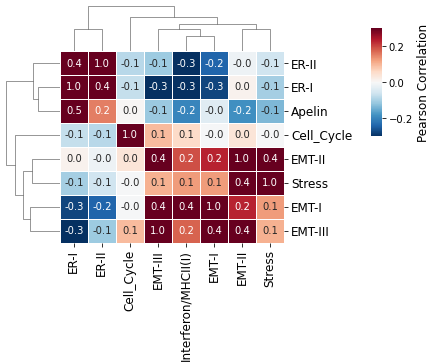

In [4]:
dt =  scores[scores.columns[scores.columns.str.startswith('MP')]].rename(columns=MP_anno_map).copy()
corr = dt.corr()
g = sns.clustermap(corr.iloc[1:,:-1],
            square=True,
            cmap='RdBu_r',
            vmax=.3,
            vmin=-.3,
            fmt=".1f",
            linewidths=1,
            cbar_kws={"shrink": .5, "label": "Pearson Correlation","location": "right" },
            annot=True,
            figsize=(5,5))

# Increase tick label sizes
g.ax_heatmap.tick_params(axis='x', labelsize=12)  # X-axis labels
g.ax_heatmap.tick_params(axis='y', labelsize=12)  # Y-axis labels

# Optional: Increase colorbar label size
g.cax.yaxis.label.set_size(12)
g.cax.set_position([1.05, 0.6, 0.03, 0.3])


## Baseline prediction

In [5]:
x='BestResponse'
timepoints =['Baseline']
explored_z=None
random_var='Patient'
x_order=['favorable response\n(RCB 0-I)','unfavorable response\n(RCB II-III)']
dt = scores.loc[(scores.Timepoint.isin(timepoints)),:].copy()
dt[x] = pd.Categorical(dt[x],x_order,ordered=True)
output_table = lmTest(dt=dt,Y=list(MP_anno_map.keys()),x=x,Z=[],explored_z=explored_z,random_var=random_var).replace(MP_anno_map)
output_table.to_csv(f'{RESULT_TABLE}/LmTest/Tumor_Baseline_Prediction.csv',index=False)
pvalues = output_table.set_index(['Y'])['Pvalue']
output_table

,Ctrl,Experiment,Y,Coef,log2FC,Pvalue,FDR
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),EMT-III,-0.761119,-1.161090,0.04234249273740533,0.095271
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),Cell_Cycle,-0.422676,-0.833897,0.08086296211581759,0.145553
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),Interferon/MHCII(I),-0.311689,-0.772014,0.2985672609366007,0.383872
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),EMT-II,-0.172943,-0.227920,0.3979641948337722,0.447710
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),EMT-I,0.059349,0.134130,0.8975016835782366,0.897502
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),Stress,0.204616,0.582758,0.22619553871934506,0.339293
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),ER-II,0.444751,1.059605,0.03744428010358418,0.095271
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),Apelin,0.642051,1.391160,0.025989677507172817,0.095271
0,favorable response\n(RCB 0-I),unfavorable response\n(RCB II-III),ER-I,0.979822,1.420367,0.03989413629173452,0.095271


In [6]:
dt[x].value_counts()

unfavorable response\n(RCB II-III)    27508
favorable response\n(RCB 0-I)          4524
Name: BestResponse, dtype: int64

In [7]:
dt.groupby(x)[random_var].nunique()

BestResponse
favorable response\n(RCB 0-I)         3
unfavorable response\n(RCB II-III)    9
Name: Patient, dtype: int64

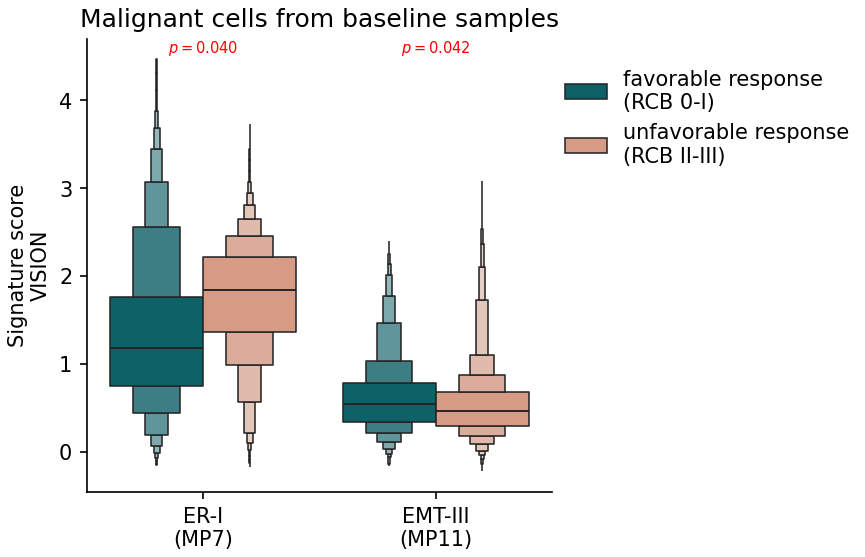

In [9]:
show_mps = ['ER-I','EMT-III']
fig,ax=plt.subplots(1,1,dpi=150,figsize=(4,4))
sns.boxenplot(data=dt.rename(columns=MP_anno_map)[show_mps+[x]].melt(id_vars=[x]),
                   ax=ax,
                x='variable',y='value',hue=x,
                   showfliers=False,
#                 split=True,inner="quart", fill=False,
                palette=COLOR_PAlETTE[x])
y_loc =ax.get_ylim()[1]
xtick_labels = []
for xtick in ax.get_xticklabels():
    x_loc,_ = xtick.get_position()
    text = xtick.get_text()
    xtick_labels.append(f"{text}\n({MP_anno_map_reverse[text]})")
    if pvalues[text] >= 0.05:
        c='gray'
        label = 'N.S.' 
    else:
        label = f"pvalue={pvalues[text]:.3f}"
        c = 'red'
    label=format_pvalue_latex(pvalues[text])
    ax.text(x_loc,y_loc,s=label,ha='center',va='top',color=c,fontsize=7)

ax.set_xticklabels(xtick_labels)
ax.set(xlabel='',ylabel=f'Signature score\nVISION',title=f'Malignant cells from baseline samples')# [{n_pt_label}]')

ax.legend(loc=(1.01,.7),frameon=False,ncol=1)
fig.savefig(f'{FIGURE_FOLDER}/Fig2C_Tumor_ER_EMT_RvsNR_Baseline.svg',dpi=200,bbox_inches='tight')

## Paired pt timepoint- resistant tumor states

### In all patients

In [10]:
x='Timepoint'
explored_z=None
random_var='Patient'
dt = scores.loc[scores.Timepoint.isin(['Baseline','W7D1']),:].copy()
paired_pts = dt[['Timepoint',random_var]].drop_duplicates()[random_var].value_counts()
paired_pts = paired_pts[paired_pts>1].index
dt= dt.loc[dt[random_var].isin(paired_pts),:]
dt.groupby([x])[random_var].nunique().rename('N_Pts').reset_index()

,Timepoint,N_Pts
0,Baseline,5
1,W7D1,5


In [11]:
dt[x] = pd.Categorical(dt[x],['Baseline','W7D1'],ordered=True)
result = lmTest(dt=dt,Y=list(MP_anno_map.keys()),x=x,Z=[],explored_z=explored_z,random_var=random_var)
significant_MP = result.Y[(result.Pvalue<0.05)&(result[f'log2FC'].abs()>.5)].unique().tolist()
result.Y =  result.Y.map(MP_anno_map)
result

,Ctrl,Experiment,Y,Coef,log2FC,Pvalue,FDR
0,Baseline,W7D1,Cell_Cycle,-0.128918,-1.026206,3.9771662822933257e-16,0.0
0,Baseline,W7D1,ER-II,-0.10349,-0.000229,3.710984371730405e-57,0.0
0,Baseline,W7D1,ER-I,-0.156861,0.039464,7.381478118516534e-32,0.0
0,Baseline,W7D1,EMT-II,-0.181142,0.051718,1.1497982950315947e-65,0.0
0,Baseline,W7D1,EMT-I,-0.13757,0.128407,6.01034901869923e-26,0.0
0,Baseline,W7D1,EMT-III,-0.016181,0.154339,0.03243407477452891,0.032434
0,Baseline,W7D1,Apelin,0.113561,0.379295,2.4310966973385607e-35,0.0
0,Baseline,W7D1,Stress,0.173459,0.810799,1.4170543601830833e-73,0.0
0,Baseline,W7D1,Interferon/MHCII(I),0.071259,0.88931,3.0510910334689414e-06,0.000003


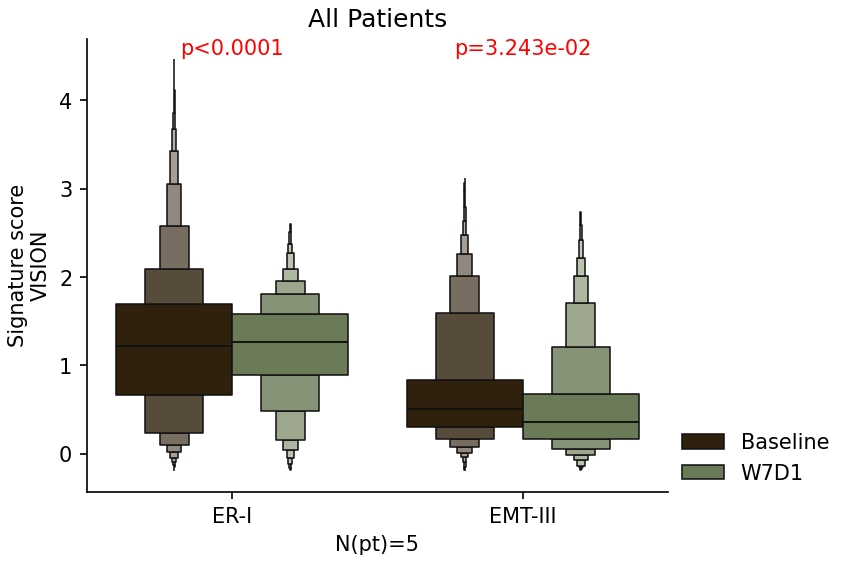

In [12]:
show_mps = ['ER-I','EMT-III']
pvalues = result.loc[(result.Y.isin(show_mps)),:].set_index('Y')['Pvalue']
dt.rename(columns=MP_anno_map,inplace=True)
fig,ax=plt.subplots(1,1,figsize=(5,4),dpi=150)
sns.boxenplot(data=dt[show_mps+[x]].melt(id_vars=[x]),
                x='variable',y='value',hue=x,showfliers=False,
                palette=COLOR_PAlETTE[x],ax=ax)
y_loc =ax.get_ylim()[1]
for xtick in ax.get_xticklabels():
    x_loc,_ = xtick.get_position()
    text = xtick.get_text()
    if pvalues[text] >= 0.05:
        c='gray'
        label = 'N.S.' 
    elif pvalues[text]<0.0001:
        label = f"p<0.0001"
        c = 'red'
    else:
        label = f"p={pvalues[text]:.3e}"
        c = 'red'
    abel=format_pvalue_latex(pvalues[text])
    ax.text(x_loc,y_loc,s=label,ha='center',va='top',color=c)
ax.set(xlabel=f"N(pt)={dt['Patient'].nunique()}",ylabel=f"Signature score\nVISION",title='All Patients')
ax.legend(loc=(1.01,0),frameon=False,ncol=1)

# Cellular abundance

In [13]:
from scipy.stats import ranksums
timepoint='Baseline'
cellstate_col = 'Cellstate'
obs = pd.read_csv(f"{RESULT_TABLE}/MPs/Tumor/Annotation.csv",index_col=0)
obs['CCG_ID'] =  obs.index.map(lambda x:'CCG1112'+x.split('CCG1112')[1][:-1])
ra = (pd.crosstab(obs[cellstate_col],obs['CCG_ID']) / obs.CCG_ID.value_counts()).T
# get RCB response groups map
sp_bp_map = sample_meta.set_index('CCG_ID')['BestResponse'].to_dict()
# perform statistic test per treatment arm

dt = ra.loc[sample_meta.CCG_ID[(sample_meta.Timepoint==timepoint)],:]
    
## order by the z score between R vs NR
##### stats_result on the distribution of relative abundance of each state
stats_result = dt.apply(lambda v: pd.Series(ranksums(v[v.index.map(sp_bp_map)=='favorable response\n(RCB 0-I)'], 
                                                 v[v.index.map(sp_bp_map)=='unfavorable response\n(RCB II-III)']),
                                        index=['statstics','Pvalue'],name=v.name),
                    axis=0).T
stats_result
pvalues = stats_result['Pvalue']
pvalues

Cellstate
Tumor.Cell_Cycle             0.355226
Tumor.EMT-II                 0.781511
Tumor.EMT-III                0.033474
Tumor.ER-I                   0.020819
Tumor.ER-II                  0.229421
Tumor.Interferon/MHCII(I)    0.229421
Name: Pvalue, dtype: float64

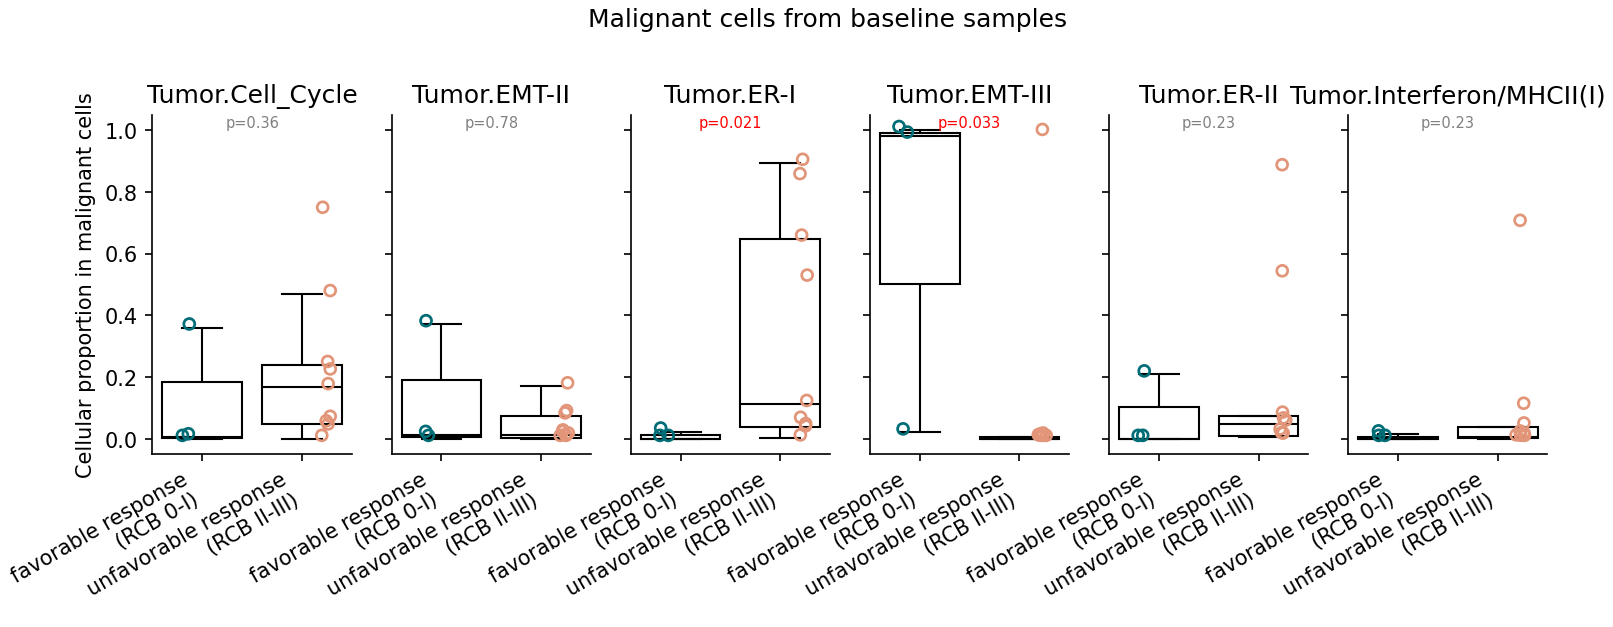

In [14]:
x = 'BestResponse'
fig,axs=plt.subplots(1,6,dpi=150,sharey=True,figsize=(12,3))
## boxplot parameters
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
filled_marker_style = dict(marker='o', linestyle=':', 
                           color='darkgrey',
                           edgecolor='brown')

for i,subtype in enumerate(['Tumor.Cell_Cycle','Tumor.EMT-II','Tumor.ER-I','Tumor.EMT-III','Tumor.ER-II','Tumor.Interferon/MHCII(I)']):
    ax=axs[i]
    plt_dt = ra.loc[sample_meta.CCG_ID[sample_meta.Timepoint==timepoint],[subtype]]
    plt_dt[x] =  sample_meta.set_index('CCG_ID').loc[plt_dt.index,x]
    sns.stripplot(data=plt_dt,
                  ax=ax,x=x,y=subtype,hue=x,
                  dodge=True,
                  palette=COLOR_PAlETTE[x], marker="$\circ$", size=10)
    sns.boxplot(data=plt_dt,
                ax=ax,x=x,y=subtype,hue=x,showfliers=False,linewidth=1,**PROPS)
    # title = subtype.replace('Tumor.','') f"{title}\n({MP_anno_map_reverse[title]})"
    ax.set(xlabel='',title=subtype,ylabel='Cellular proportion in malignant cells')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    y_loc =1.05
    if pvalues[subtype] >= 0.05:
        c='gray'
        label = f"p={pvalues[subtype]:.2f}"
    else:
        label = f"p={pvalues[subtype]:.3f}"
        c = 'red'
    abel=format_pvalue_latex(pvalues[subtype])
    ax.text(0.5,y_loc,s=label,ha='center',va='top',color=c,fontsize=7)
    
plt.suptitle('Malignant cells from baseline samples',y=1.12)
fig.savefig(f'{FIGURE_FOLDER}/Suppl_XX_Tumor_ER_EMT_RvsNR_Baseline_Pct.svg',dpi=200,bbox_inches='tight')

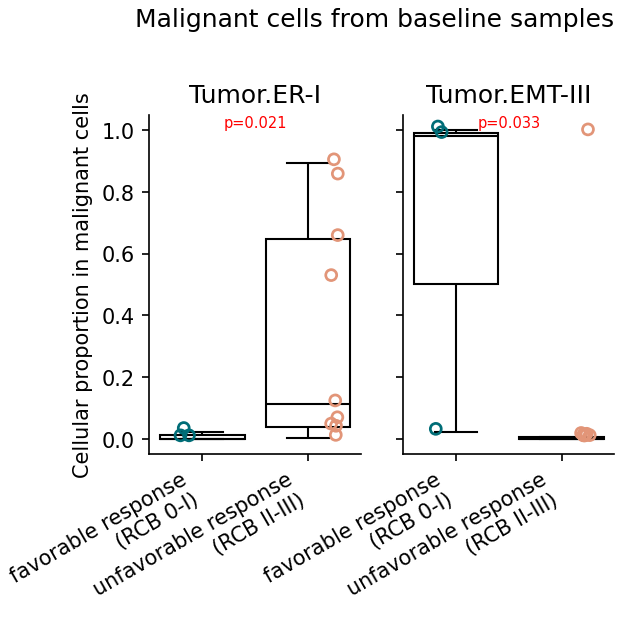

In [15]:
x = 'BestResponse'
fig,axs=plt.subplots(1,2,dpi=150,sharey=True,figsize=(4,3))
## boxplot parameters
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
filled_marker_style = dict(marker='o', linestyle=':', 
                           color='darkgrey',
                           edgecolor='brown')

for i,subtype in enumerate(['Tumor.ER-I','Tumor.EMT-III']):
    ax=axs[i]
    plt_dt = ra.loc[sample_meta.CCG_ID[sample_meta.Timepoint==timepoint],[subtype]]
    plt_dt[x] =  sample_meta.set_index('CCG_ID').loc[plt_dt.index,x]
    sns.stripplot(data=plt_dt,
                  ax=ax,x=x,y=subtype,hue=x,
                  dodge=True,
                  palette=COLOR_PAlETTE[x], marker="$\circ$", size=10)
    sns.boxplot(data=plt_dt,
                ax=ax,x=x,y=subtype,hue=x,showfliers=False,linewidth=1,**PROPS)
    # title = subtype.replace('Tumor.','') f"{title}\n({MP_anno_map_reverse[title]})"
    ax.set(xlabel='',title=subtype,ylabel='Cellular proportion in malignant cells')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    y_loc =1.05
    if pvalues[subtype] >= 0.05:
        c='gray'
        label = f"p={pvalues[subtype]:.2f}"
    else:
        label = f"p={pvalues[subtype]:.3f}"
        c = 'red'
    abel=format_pvalue_latex(pvalues[subtype])
    ax.text(0.5,y_loc,s=label,ha='center',va='top',color=c,fontsize=7)
    
plt.suptitle('Malignant cells from baseline samples',y=1.12)
fig.savefig(f'{FIGURE_FOLDER}/Fig2D_Tumor_ER_EMT_RvsNR_Baseline_Pct.svg',dpi=200,bbox_inches='tight')

In [16]:
Cellstate_Names = obs.Cellstate.unique().tolist()

In [17]:
dt['PAM50'] = sample_meta.set_index('CCG_ID')['BluePrint']
dt['Sample']= sample_meta.reset_index().set_index('CCG_ID')['Patient']

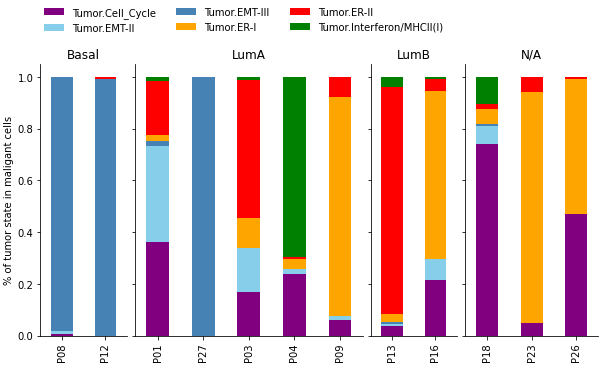

In [18]:
fig,axs=plt.subplot_mosaic([
    ['Basal']*(dt.PAM50=='Basal').sum()+\
      ['LumA']*(dt.PAM50=='LumA').sum()+\
      ['LumB']*(dt.PAM50=='LumB').sum()+\
      ['Normal']*(dt.PAM50=='Normal').sum()+\
      ['N/A']*(dt.PAM50=='N/A').sum()
],sharey=True,figsize=(10,5))
for subtype,sub_dt in dt.groupby('PAM50'):
    ax=axs[subtype]
    sub_dt = sub_dt.drop(['PAM50'],axis=1).set_index('Sample')
    sub_dt.plot(kind='bar',color=[COLOR_PAlETTE['Cellstate'][c] for c in sub_dt],ax=ax,stacked=True)
    ax.set(title=subtype,ylabel='% of tumor state in maligant cells',xlabel='')
    if subtype !='Basal':
        ax.legend_.remove()
    else:
        ax.legend(loc=(0,1.1),ncols=3)
    

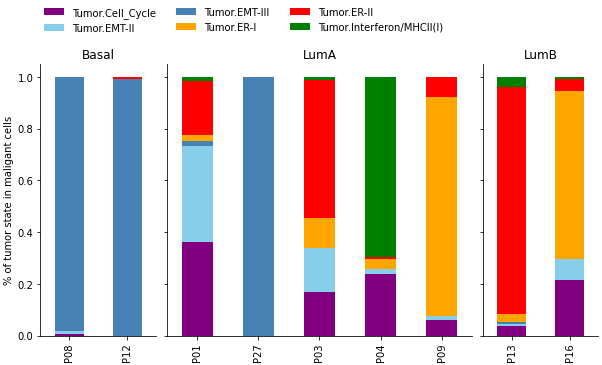

In [19]:
fig,axs=plt.subplot_mosaic([
    ['Basal']*(dt.PAM50=='Basal').sum()+\
      ['LumA']*(dt.PAM50=='LumA').sum()+\
      ['LumB']*(dt.PAM50=='LumB').sum()
],sharey=True,figsize=(10,5))
for subtype,sub_dt in dt.groupby('PAM50'):
    if subtype=='N/A':
        continue
    ax=axs[subtype]
    sub_dt = sub_dt.drop(['PAM50'],axis=1).set_index('Sample')
    sub_dt.plot(kind='bar',color=[COLOR_PAlETTE['Cellstate'][c] for c in sub_dt],ax=ax,stacked=True)
    ax.set(title=subtype,ylabel='% of tumor state in maligant cells',xlabel='')
    if subtype !='Basal':
        ax.legend_.remove()
    else:
        ax.legend(loc=(0,1.1),ncols=3)
fig.savefig(f'{FIGURE_FOLDER}/Suppl_2H_Tumor_PAM50.svg',dpi=200,bbox_inches='tight')

In [20]:
dt['PAM50'].value_counts()

LumA     5
N/A      3
Basal    2
LumB     2
Name: PAM50, dtype: int64

# External validation- Predictive value
## Generate GMT for tumor cellstates for the signature level evaluation in bulk RNA-Seq
1. Perform ``utils/run_DEGs.py`` to compare each tumor cell states to the rest of all cell population
2. Create signature for each tumor cell stats by selecting their top 100 genes. 

In [22]:
with open(f'{RESULT_TABLE}/Tumor_Cellstate.gmt','w') as f:
    for cellstate in Cellstate_Names:
        print(cellstate)
        sheet_name = cellstate.replace('/','_')  if '/' in cellstate else cellstate
        degs = pd.read_excel(f"{RESULT_TABLE}/DEGs_Cellstate.xlsx",sheet_name=sheet_name,index_col=0)
        degs = degs.sort_values('stat',ascending=False).index[(degs.padj<0.05) & (degs.log2FoldChange>1)].tolist()[:100]
        f.write('\t'.join([cellstate,'All_cells']+degs)+'\n')

Tumor.EMT-III
Tumor.ER-II
Tumor.ER-I
Tumor.Cell_Cycle
Tumor.Interferon/MHCII(I)
Tumor.EMT-II


### keenan et al., 2021

In [23]:
from utils.misc import mergeRsemGeneOutput
clin = pd.read_excel(f'{EXTERNAL_DATA}/Keenan_2021_SourceData/41467_2021_25769_MOESM5_ESM.xlsx',
                   skiprows=1,sheet_name='Fig 1, 2, 6a-c, Suppl Fig 3, 4',index_col=0)
clin.index=clin.index.map(lambda x:f"P{x}")
# get counts
qced_pts =  pd.read_excel(f'{EXTERNAL_DATA}/Keenan_2021_SourceData/41467_2021_25769_MOESM5_ESM.xlsx',
                   skiprows=1,sheet_name='Suppl Fig 7, 8d-e, 9e-f',index_col=0).columns.str.replace('Patient','P').tolist()
counts,tpm= mergeRsemGeneOutput(f'{EXTERNAL_DATA}/Keenan_2021_SourceData/rsem')
counts.index = counts.index.map(lambda x: '_'.join(x.split('_')[1:])).str.replace('^[0-9]_','')
counts = counts.groupby(level=0).mean().round(0)
counts.columns = counts.columns.map(lambda x: 'P'+str(int(x.split('_')[-1])))

In [24]:
counts.to_csv(f'{EXTERNAL_DATA}/Keenan_2021_SourceData/counts.tsv',sep='\t')

### Signature calculation

In [25]:
keenan = anndata.AnnData(X=counts.T,obs=clin.loc[counts.columns,:])
keenan = keenan[(keenan.obs.Therapy!='Eribulin') &(keenan.obs.Biopsy!='Metastatic'),:]
keenan.obs['Clinical Benefit'] = keenan.obs['Clinical Benefit'].map({1:"CB",0:"NCB"})
n_umi = keenan.X.sum(axis=1)
scaled_counts = (keenan.X.T / n_umi) * np.median(n_umi)
keenan.X = scaled_counts.T
mp_result = sp.ext.VISION(data=keenan,gmt_files=[f"{RESULT_TABLE}/Tumor_Cellstate.gmt"],outdir='.')

Rscript /home/analysis/scPipe/scPipe/Rscripts/VISION.R --gmt_files ../data/table/Tumor_Cellstate.gmt --h5ad /tmp/tmpxe2f91ek/count.h5ad --output_file /tmp/tmpxe2f91ek/vision.tsv
$gmt_files
[1] "../data/table/Tumor_Cellstate.gmt"

$h5ad
[1] "/tmp/tmpxe2f91ek/count.h5ad"

$output_file
[1] "/tmp/tmpxe2f91ek/vision.tsv"



Loading data from ../data/table/Tumor_Cellstate.gmt ...

Using 29132/57829 genes detected in 0.10% of cells for signature analysis.
See the `sig_gene_threshold` input to change this behavior.

Evaluating signature scores on cells...

'as(<matrix>, "dgeMatrix")' is deprecated.
Use 'as(as(as(., "dMatrix"), "generalMatrix"), "unpackedMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").
Evaluating signature-gene importance...



### visualization on boxplot

In [26]:
norm_score = mp_result.rename(columns=MP_anno_map)
norm_score = (norm_score.T - norm_score.mean(axis=1)).T 

In [27]:
norm_score['Response'] = keenan.obs['Response']

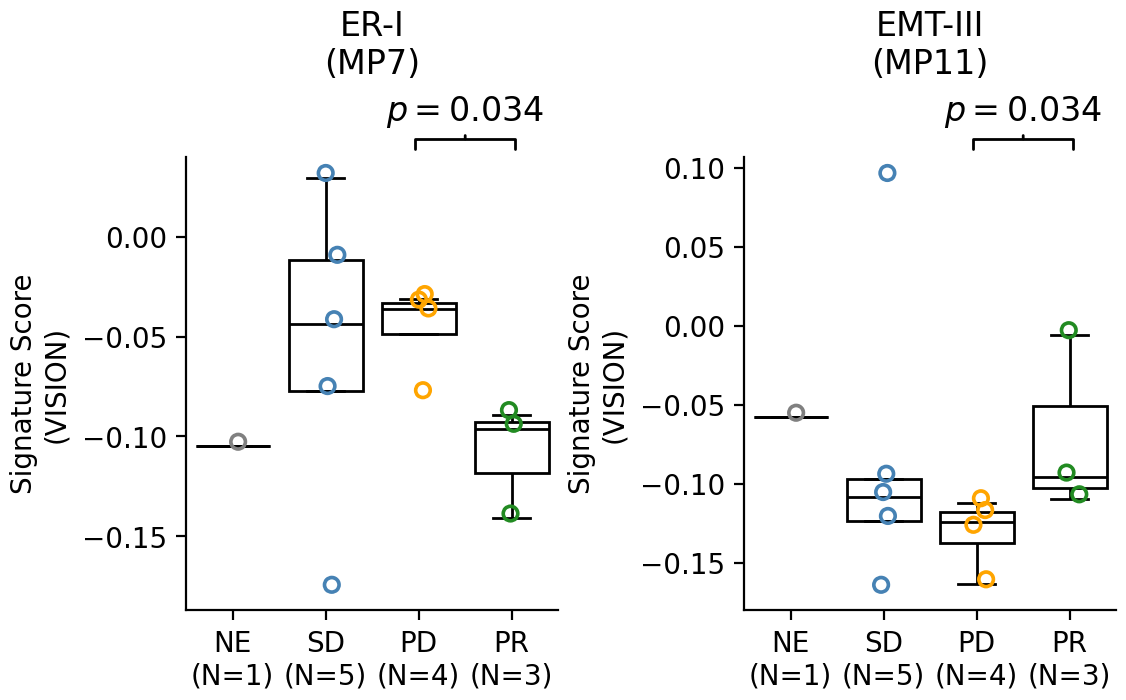

In [29]:
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=['NE','SD','PD','PR']
palette={'NE':'gray','PD':'orange','SD':'steelblue','PR':'forestgreen'}
ylabel='Signature Score\n(VISION)'
x='Response'
fig,axs = plt.subplots(1,2,figsize=(6,3),dpi=200)

## Plot EMT-III
ax=axs[0]
# y='Interferon/MHCII(I)'
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='PR',y].values,
                  norm_score.loc[norm_score[x].isin(['PD']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.75, 1.04), xytext=(0.75, 1.06), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=.3', lw=1, color='k'))
# ax.annotate('', xy=(0.5, .93), xytext=(0.5, 0.9301), xycoords='axes fraction', 
#             fontsize=12, ha='center', va='bottom',
#             arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=.2', lw=1, color='k'))

## Plot ER-I
ax=axs[1]
y='Tumor.EMT-III'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)

ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='PR',y].values,
                  norm_score.loc[norm_score[x].isin(['PD']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.75, 1.04), xytext=(0.75, 1.06), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=.3', lw=1, color='k'))
# ax.annotate('', xy=(0.5, 1), xytext=(0.5, 1.001), xycoords='axes fraction', 
#             fontsize=12, ha='center', va='bottom',
#             arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=.2', lw=1, color='k'))

plt.subplots_adjust(wspace=.5)
fig.savefig(f'{FIGURE_FOLDER}/Suppl_2H_ERI_EMTIII_Keenan_et_al.svg',dpi=200,bbox_inches='tight')

### Waks et al., under-review

In [30]:
counts = pd.read_csv(f'{EXTERNAL_DATA}/Waks_2025/bulkRNA_Count.csv',index_col=0)
clin = pd.read_csv(f'{EXTERNAL_DATA}/clin_IHC.csv',index_col=0)

In [31]:
waks = anndata.AnnData(X=counts.T,obs=clin.loc[counts.columns,['Timepoint','BestResponse']])
waks = waks[waks.obs.Timepoint=='Baseline',:]
n_umi = waks.X.sum(axis=1)
scaled_counts = (waks.X.T / n_umi) * np.median(n_umi)
waks.X = scaled_counts.T
mp_result = sp.ext.VISION(data=waks,gmt_files=[f"{RESULT_TABLE}/Tumor_Cellstate.gmt"],outdir='.')

Rscript /home/analysis/scPipe/scPipe/Rscripts/VISION.R --gmt_files ../data/table/Tumor_Cellstate.gmt --h5ad /tmp/tmpvszl95ci/count.h5ad --output_file /tmp/tmpvszl95ci/vision.tsv
$gmt_files
[1] "../data/table/Tumor_Cellstate.gmt"

$h5ad
[1] "/tmp/tmpvszl95ci/count.h5ad"

$output_file
[1] "/tmp/tmpvszl95ci/vision.tsv"



Loading data from ../data/table/Tumor_Cellstate.gmt ...

Using 33016/57787 genes detected in 0.10% of cells for signature analysis.
See the `sig_gene_threshold` input to change this behavior.

Evaluating signature scores on cells...

'as(<matrix>, "dgeMatrix")' is deprecated.
Use 'as(as(as(., "dMatrix"), "generalMatrix"), "unpackedMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").
Evaluating signature-gene importance...



### visualization on boxplot

In [32]:
norm_score = mp_result.rename(columns=MP_anno_map)
norm_score = (norm_score.T - norm_score.mean(axis=1)).T 

In [33]:
norm_score['Response'] = waks.obs['BestResponse']

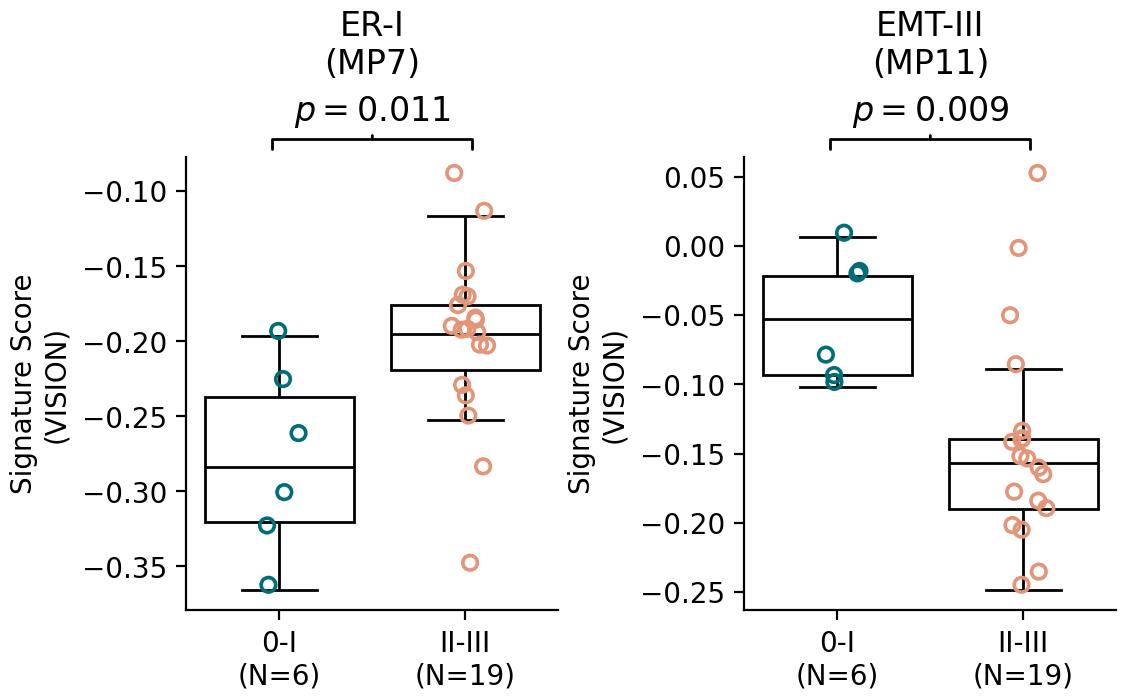

In [34]:
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=['0-I','II-III']
palette={'0-I':COLOR_PAlETTE['BestResponse']['favorable response\n(RCB 0-I)'],'II-III':COLOR_PAlETTE['BestResponse']['unfavorable response\n(RCB II-III)']}
ylabel='Signature Score\n(VISION)'
x='Response'
fig,axs = plt.subplots(1,2,figsize=(6,3),dpi=200)

## Plot EMT-III
ax=axs[0]
# y='Interferon/MHCII(I)'
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='0-I',y].values,
                  norm_score.loc[norm_score[x].isin(['II-III']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, 1.04), xytext=(0.5, 1.06), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=3, lengthB=.3', lw=1, color='k'))


## Plot ER-I
ax=axs[1]
y='Tumor.EMT-III'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)

ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='0-I',y].values,
                  norm_score.loc[norm_score[x].isin(['II-III']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, 1.04), xytext=(0.5, 1.06), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=3, lengthB=.3', lw=1, color='k'))


plt.subplots_adjust(wspace=.5)
fig.savefig(f'{FIGURE_FOLDER}/Suppl_XX_ERI_EMTIII_Waks_et_al.svg',dpi=200,bbox_inches='tight')

# Progeny pathway activity
## Activity inference with Multivariate Linear Model (MLM)

In [42]:
import decoupler as dc
progeny_ref_path = f"{RESULT_TABLE}/progeny_reference.csv"
progeny_path = f"{RESULT_TABLE}/Progeny.xlsx"
progeny = dc.get_progeny(organism='human', top=500)
progeny.to_csv(progeny_ref_path,index=False)

Within tumor population, perform the DEGs per cell state. see `run_DEGs.py`

In [43]:
pathway_acts = []
pathway_pvals =[]
for cellstate in Cellstate_Names:
    sheet_name = cellstate.replace('/','_')  if '/' in cellstate else cellstate
    stat_df = pd.read_excel(f"{RESULT_TABLE}/DEGs_Tumor.xlsx",sheet_name=sheet_name,index_col=0)[['stat']].T.rename(index={'stat':cellstate})
    # Infer pathway activities with mlm
    pathway_act, pathway_pval = dc.run_mlm(mat=stat_df, net=progeny)
    pathway_acts.append(pathway_act)
    pathway_pvals.append(pathway_pval)
# store result
with pd.ExcelWriter(progeny_path) as f:
    pd.concat(pathway_acts).to_excel(f,sheet_name='Activity',index=True)
    pd.concat(pathway_pvals).to_excel(f,sheet_name='Pvalue',index=True)

## Visualization

In [44]:
pathway_acts = pd.read_excel(progeny_path,sheet_name='Activity',index_col=0)
progeny = pd.read_csv(progeny_ref_path)

degs_dict = {}
degs_path = f"{RESULT_TABLE}/DEGs_Tumor.xlsx"
# for cellstate in  obs.Cellstate.unique():
for cellstate in Cellstate_Names:
    sheet_name = cellstate.replace('/','_')  if '/' in cellstate else cellstate
    degs_dict[cellstate] = pd.read_excel(degs_path,sheet_name=sheet_name,index_col=0)
    

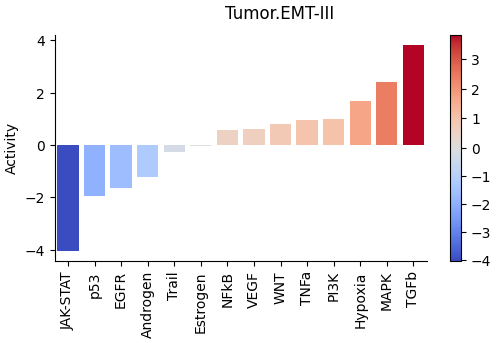

In [45]:
contrast='Tumor.EMT-III'
fig=dc.plot_barplot(
    acts=pathway_acts,
    contrast=contrast,
    top=25,
    vertical=False,
    figsize=(6, 3),
    return_fig=True
)
# title=contrast.replace('Tumor.','')
# fig.suptitle(f"{title}\n({MP_anno_map_reverse[title]})")
fig.suptitle(contrast)
fig.savefig(f'{FIGURE_FOLDER}/Progeny_EMT-III_activity.svg',dpi=200)

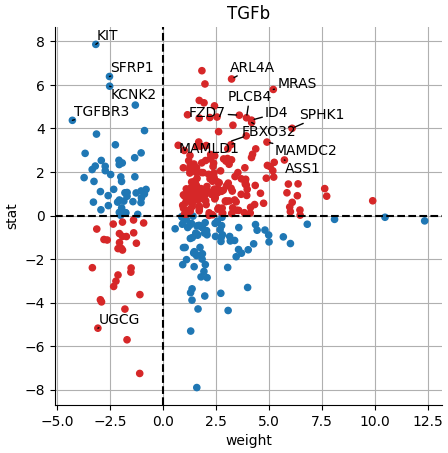

In [46]:
fig=dc.plot_targets(
    data=degs_dict[contrast],
    stat='stat',
    source_name='TGFb',
    net=progeny,
    top=15,
    return_fig=True
)
fig.savefig(f'{FIGURE_FOLDER}/Progeny_EMT-III_vocalno.svg',dpi=200)

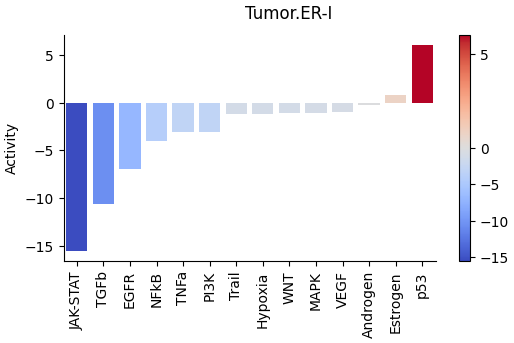

In [47]:
contrast='Tumor.ER-I'
fig=dc.plot_barplot(
    acts=pathway_acts,
    contrast=contrast,
    top=25,
    vertical=False,
    figsize=(6, 3),
    return_fig=True
)
# title=contrast.replace('Tumor.','')
# fig.suptitle(f"{title}\n({MP_anno_map_reverse[title]})")
fig.suptitle(contrast)
fig.savefig(f'{FIGURE_FOLDER}/Progeny_ER-I_activity.svg',dpi=200)

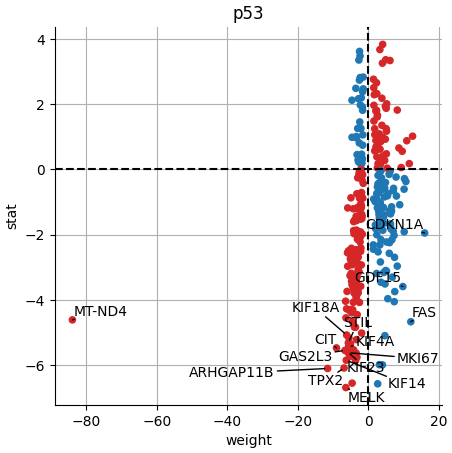

In [48]:
fig=dc.plot_targets(
    data=degs_dict[contrast],
    stat='stat',
    source_name='p53',
    net=progeny,
    top=15,
    return_fig=True
)
fig.savefig(f'{FIGURE_FOLDER}/Progeny_ER-I_vocalno.svg',dpi=200)

# p53 alteration

### Celular abudance

In [49]:
## Mutation data
mutation_data = pd.read_csv(f'{RESULT_TABLE}/somatic_mutation.csv')
mut_tab = (pd.crosstab(mutation_data['sample'],mutation_data['category'])>0).astype(int)

In [50]:
mut_tab.columns[mut_tab.columns.str.startswith('MD')]

Index(['MDGA2', 'MDN1'], dtype='object', name='category')

In [51]:
celltype='Tumor'
gene ='TP53'
dt_bl = ra.loc[sample_meta.CCG_ID[(sample_meta.Timepoint=='Baseline')],:].copy()
dt_bl['BestResponse'] = sample_meta.set_index('CCG_ID').loc[dt_bl.index,'BestResponse']
dt_bl.index = dt_bl.index.map(sample_meta.reset_index().set_index('CCG_ID')['sample'].to_dict())
dt_bl[gene] = mut_tab[gene].map({1:'Mut',0:'WT'})
dt_bl.sort_values('TP53')

Cellstate,Tumor.Cell_Cycle,Tumor.EMT-II,Tumor.EMT-III,Tumor.ER-I,Tumor.ER-II,Tumor.Interferon/MHCII(I),BestResponse,TP53
P01.T1,0.360620,0.371276,0.021070,0.023735,0.208767,0.014531,favorable response\n(RCB 0-I),Mut
P08.T1,0.005168,0.012920,0.981912,0.000000,0.000000,0.000000,favorable response\n(RCB 0-I),Mut
P12.T1,0.000000,0.000000,0.990573,0.001571,0.007855,0.000000,unfavorable response\n(RCB II-III),Mut
P27.T1,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,favorable response\n(RCB 0-I),WT
P03.T1,0.167590,0.170213,0.002332,0.113087,0.532789,0.013990,unfavorable response\n(RCB II-III),WT
P04.T1,0.239302,0.017674,0.000698,0.038140,0.007907,0.696279,unfavorable response\n(RCB II-III),WT
P09.T1,0.061868,0.012879,0.000000,0.847516,0.075207,0.002530,unfavorable response\n(RCB II-III),WT
P13.T1,0.037094,0.007728,0.007728,0.030912,0.876352,0.040185,unfavorable response\n(RCB II-III),WT
P16.T1,0.215112,0.080185,0.000000,0.648419,0.049345,0.006939,unfavorable response\n(RCB II-III),WT
P18.T1,0.738467,0.072841,0.005203,0.058619,0.020812,0.104058,unfavorable response\n(RCB II-III),WT


### visualization

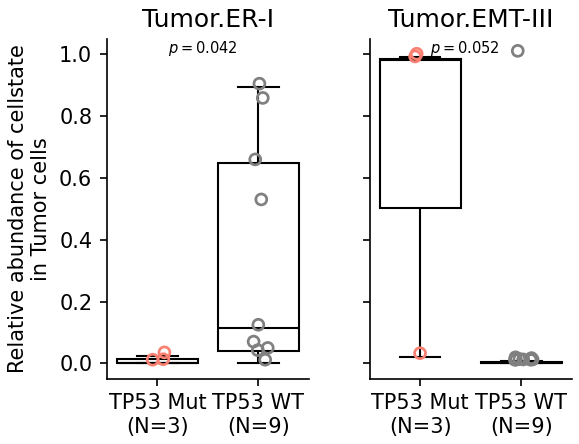

In [52]:
timepoint='Baseline'
gene='TP53'
fig,axs = plt.subplots(1,2,figsize=(4,3),sharey=True,dpi=150)
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
filled_marker_style = dict(marker='o', linestyle=':', 
                           color='darkgrey',
                           edgecolor='brown')
ax=axs[0]
celltype='Tumor'
cellstate = 'ER-I'

sns.stripplot(data=dt_bl,x=gene,y=f'{celltype}.{cellstate}',ax=ax,palette={'Mut':'salmon','WT':'gray'}, marker="$\circ$", ec="face",size=10)
sns.boxplot(data=dt_bl,x=gene,y=f'{celltype}.{cellstate}',ax=ax,showfliers=False,linewidth=1,**PROPS)
_,pvalue = ranksums(dt_bl.loc[dt_bl[gene]=='Mut',f"{celltype}.{cellstate}"],
         dt_bl.loc[dt_bl[gene]=='WT',f"{celltype}.{cellstate}"])
ax.text(0.3,1,s=format_pvalue_latex(pvalue),transform = ax.transAxes,va='top',ha='left',size=7)
ax.set(xlabel='',title=f"Tumor.{cellstate}",ylabel=f'Relative abundance of cellstate\nin {celltype} cells');
ax.spines[['right','top']].set_visible(False)
xticklabels = []
for handle in ax.get_xticklabels():
    mut_status = handle.get_text()
    xticklabels.append(f"{gene} {mut_status}\n(N={(dt_bl[gene]==mut_status).sum()})")
ax.set_xticklabels(xticklabels)

ax=axs[1]
celltype='Tumor'
cellstate = 'EMT-III'
dt_bl.dropna(axis=0,inplace=True)# remove samples without WES

sns.stripplot(data=dt_bl,x=gene,y=f'{celltype}.{cellstate}',ax=ax,palette={'Mut':'salmon','WT':'gray'}, marker="$\circ$", ec="face",size=10)
sns.boxplot(data=dt_bl,x=gene,y=f'{celltype}.{cellstate}',ax=ax,showfliers=False,linewidth=1,**PROPS)
_,pvalue = ranksums(dt_bl.loc[dt_bl[gene]=='Mut',f"{celltype}.{cellstate}"],
         dt_bl.loc[dt_bl[gene]=='WT',f"{celltype}.{cellstate}"])
ax.text(0.3,1,s=format_pvalue_latex(pvalue),transform = ax.transAxes,va='top',ha='left',size=7)

ax.set(xlabel='',title=f"Tumor.{cellstate}",ylabel=f'Relative abundance of cellstate\nin {celltype} cells');
ax.spines[['right','top']].set_visible(False)
xticklabels = []
for handle in ax.get_xticklabels():
    mut_status = handle.get_text()
    xticklabels.append(f"{gene} {mut_status}\n(N={(dt_bl[gene]==mut_status).sum()})")
ax.set_xticklabels(xticklabels)
plt.subplots_adjust(wspace=.3)
fig.savefig(f'{FIGURE_FOLDER}/Fig2G_p53_ERI_EMTIII_cohort.svg',dpi=200,bbox_inches='tight')

## External Validation on TCGA

In [53]:
## Data Preperation
brca = sc.read(f"{EXTERNAL_DATA}/BRCA.h5ad")
# from cbioportal
#https://www.cbioportal.org/study/summary?id=brca_tcga_pub2015%2Cbrca_tcga%2Cbrca_tcga_pan_can_atlas_2018%2Cbrca_tcga_pub
her2_status = pd.read_csv(f'{EXTERNAL_DATA}/IHC-HER2.full.txt',sep='\t')
er_status = pd.read_csv(f'{EXTERNAL_DATA}/ER_Status_By_IHC.full.txt',sep='\t')
purity=pd.read_csv('http://api.gdc.cancer.gov/data/4f277128-f793-4354-a13d-30cc7fe9f6b5',sep='\t').set_index('array')['purity']
pam50 = pd.read_csv(f'{EXTERNAL_DATA}/TCGA_PAM50_balanced_all_data_FINAL.tsv',sep='\t',index_col=1)['PAM50.subtype']

brca.obs['HER2-IHC'] = her2_status.set_index('Sample ID')['IHC-HER2']
brca.obs['ER-IHC'] = er_status.set_index('Sample ID')['ER Status By IHC']
brca.obs['Tumor_Purity'] = purity
brca.obs['PAM50_Subtype'] = pam50
# brca.obs['Patient'] = brca.obs.index.map(lambda x:'-'.join(x.split('-')[:3]))
del her2_status,er_status,purity

## subset primary  breast cancer
primary_brca = brca[(brca.obs['sample_type.samples']=='Primary Tumor')&
            (brca.obs.Is_Tumor_Biopsy&
            (~brca.obs['Tumor_Purity'].isna()))&
            (brca.obs['prior_malignancy.diagnoses']=='no')&
            (brca.obs['history_of_neoadjuvant_treatment']=='No')&
            (brca.obs['distant_metastasis_present_ind2']=='NO')&
            (brca.obs['gender.demographic']=='female'),:] # with purity information

## subset primary hr+ breast cancer
er_primary_brca = primary_brca[
    (primary_brca.obs['HER2-IHC'].isin(['Negative', 'Equivocal']))&
    (primary_brca.obs['ER-IHC']=='Positive'),:]

## output data
primary_brca.write(f'{EXTERNAL_DATA}/tcga_primary_brca.h5ad')
er_primary_brca.write(f'{EXTERNAL_DATA}/tcga_primary_hr_pos_brca.h5ad')

## Load data
brca = sc.read(f'{EXTERNAL_DATA}/tcga_primary_brca.h5ad')
mut = sc.read(f'{EXTERNAL_DATA}/TCGA_BRCA_Mutation.h5ad')
brca.obs =brca.obs.merge(sc.get.obs_df(mut,['TP53']),left_index=True,right_index=True,
                         how='left')

In [54]:
# her2_status = pd.read_csv(f'{EXTERNAL_DATA}/IHC-HER2.full.txt',sep='\t')
# er_status = pd.read_csv(f'{EXTERNAL_DATA}/ER_Status_By_IHC.full.txt',sep='\t')
# her2_status.set_index('Sample ID').index[her2_status['IHC-HER2'].isin(['Negative','Equivocal'])].intersection(
#     er_status.set_index('Sample ID').index[er_status['ER Status By IHC'].isin(['Negative'])]
# ).to_series().to_csv(f'{EXTERNAL_DATA}/TCGA_TNBC_Sample_List.txt',index=False)

### Calculate MP scores via VISION

In [55]:
n_umi = brca.X.toarray().sum(axis=1)
scaled_counts = (brca.X.toarray().T / n_umi) * np.median(n_umi)
brca.X = scaled_counts.T

In [56]:
mp_result = sp.ext.VISION(data=brca,gmt_files=[f"{RESULT_TABLE}/Tumor_Cellstate.gmt"],outdir='.')

Rscript /home/analysis/scPipe/scPipe/Rscripts/VISION.R --gmt_files ../data/table/Tumor_Cellstate.gmt --h5ad /tmp/tmp7j25kom9/count.h5ad --output_file /tmp/tmp7j25kom9/vision.tsv
$gmt_files
[1] "../data/table/Tumor_Cellstate.gmt"

$h5ad
[1] "/tmp/tmp7j25kom9/count.h5ad"

$output_file
[1] "/tmp/tmp7j25kom9/vision.tsv"



Loading data from ../data/table/Tumor_Cellstate.gmt ...

Using 55800/58387 genes detected in 0.10% of cells for signature analysis.
See the `sig_gene_threshold` input to change this behavior.

Evaluating signature scores on cells...

Evaluating signature-gene importance...



### Normalization

In [57]:
v_score = mp_result.copy()
norm_v_score = (v_score.T - v_score.mean(axis=1)).T 
norm_v_score['TP53'] = brca.obs.loc[norm_v_score.index,'TP53']
norm_v_score.dropna(subset=['TP53'],inplace=True)
norm_v_score ['TP53']=norm_v_score['TP53'].map(lambda x:'Mut' if x > 0 else 'WT')
norm_v_score['ER-IHC'] = brca.obs.loc[norm_v_score.index,'ER-IHC']
norm_v_score['HER2-IHC'] = brca.obs.loc[norm_v_score.index,'HER2-IHC']
norm_v_score['PAM50'] = brca.obs.loc[norm_v_score.index,'PAM50_Subtype']
norm_v_score = norm_v_score.loc[norm_v_score['ER-IHC']!='Indeterminate',:]

### Visualization

#### In TCGA primary ER- breast cancer, we did not observe significant association between ER-I and TP53 mutation.

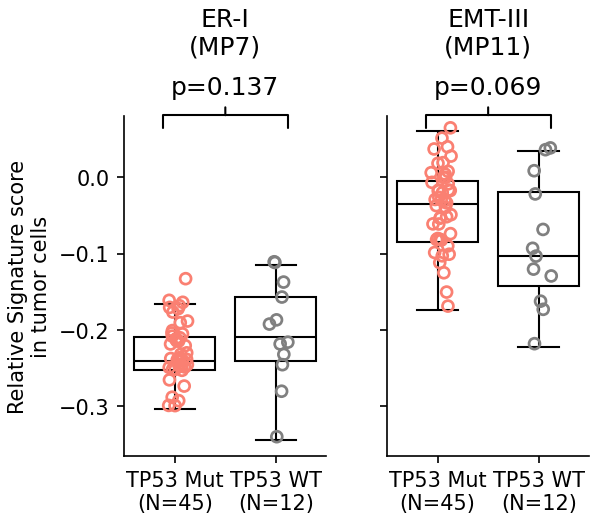

In [58]:
from scipy.stats import ranksums
norm_score = norm_v_score.loc[norm_v_score['ER-IHC']=='Negative',:]
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=['Mut','WT']
palette={'WT':'gray','Mut':'salmon'}
ylabel='Relative Signature score\nin tumor cells'
x='TP53'
fig,axs = plt.subplots(1,2,figsize=(4,3),sharey=True,dpi=150)

## Plot EMT-III
ax=axs[1]
# y='Tumor.Interferon/MHCII(I)'
y='Tumor.EMT-III'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"TP53 {text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Mut',y].values,
                  norm_score.loc[norm_score[x].isin(['WT']),y].values)
ax.annotate(f"p={pvalue:.3f}", xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

## Plot ER-I
ax=axs[0]
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"TP53 {text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Mut',y].values,
                  norm_score.loc[norm_score[x].isin(['WT']),y].values)
ax.annotate(f"p={pvalue:.3f}" if pvalue >0.0001 else 'p<0.0001', xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

plt.subplots_adjust(wspace=.3)

#### In TCGA primary ER+ breast cancer, we did observed that patients harboring mutations in TP53 genes have significant lower ER-I signatures

Tumor.EMT-III
p=0.000886
Tumor.ER-I
p=0.000011


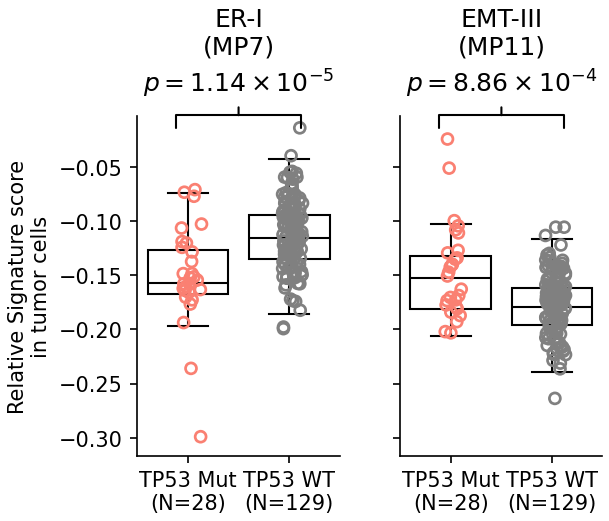

In [63]:
norm_score = norm_v_score.loc[(norm_v_score['ER-IHC']=='Positive')&
(norm_v_score['HER2-IHC'].isin(['Negative', 'Equivocal'])),:]
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=['Mut','WT']
palette={'WT':'gray','Mut':'salmon'}
ylabel='Relative Signature score\nin tumor cells'
x='TP53'
fig,axs = plt.subplots(1,2,figsize=(4,3),sharey=True,dpi=150)

## Plot EMT-III
ax=axs[1]
# y='Tumor.Interferon/MHCII(I)'
y='Tumor.EMT-III'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"TP53 {text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Mut',y].values,
                  norm_score.loc[norm_score[x].isin(['WT']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))
print(y)
print(f"p={pvalue:.6f}")
## Plot ER-I
ax=axs[0]
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"TP53 {text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Mut',y].values,
                  norm_score.loc[norm_score[x].isin(['WT']),y].values)
print(y)
print(f"p={pvalue:.6f}")
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

plt.subplots_adjust(wspace=.3)
fig.savefig(f'{FIGURE_FOLDER}/Fig2H_p53_ERI_EMTIII_TCGA_HR+_BRCA.svg',dpi=200,bbox_inches='tight')

#### ER signaures are enriched in tumors with positive IHC staining for ER.

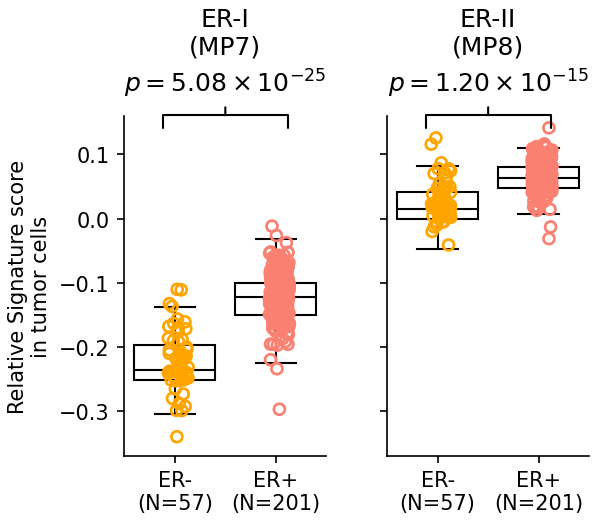

In [64]:
norm_score = norm_v_score.copy()#loc[norm_v_score['TP53']=='WT',:]
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=[ 'Negative', 'Positive']
palette={'Negative':'orange','Positive':'salmon'}
text_map = {'Positive':'+', 'Negative':'-'}
ylabel='Relative Signature score\nin tumor cells'
x='ER-IHC'
fig,axs = plt.subplots(1,2,figsize=(4,3),sharey=True,dpi=150)

## Plot EMT-III
ax=axs[1]
# y='Tumor.Interferon/MHCII(I)'
y='Tumor.ER-II'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"ER{text_map[text]}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Positive',y].values,
                  norm_score.loc[norm_score[x].isin(['Negative']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

## Plot ER-I
ax=axs[0]
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
title=y.replace('Tumor.','')
ax.set_title(f"{title}\n({MP_anno_map_reverse[title]})",pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"ER{text_map[text]}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Positive',y].values,
                  norm_score.loc[norm_score[x].isin(['Negative']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

plt.subplots_adjust(wspace=.3)
fig.savefig(f"{FIGURE_FOLDER}/Suppl_2F_ER_staining_ERI_ERII_TCGA.svg",dpi=200,bbox_inches='tight')

#### For patients with mutations on TP53, ER-I signaure is enriched in tumors with positive IHC staining for ER.

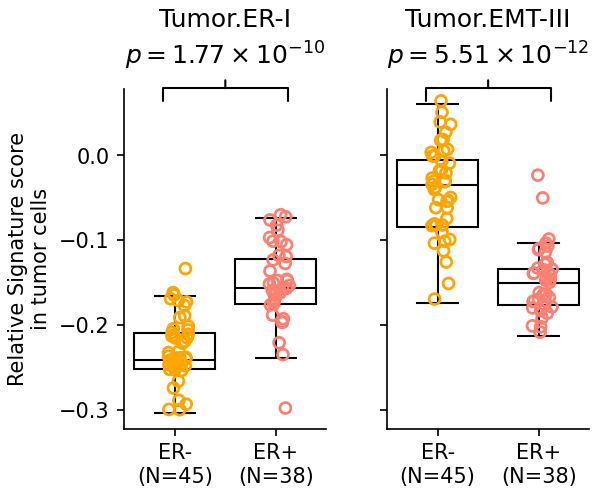

In [65]:
norm_score = norm_v_score.loc[norm_v_score['TP53']=='Mut',:]
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=[ 'Negative', 'Positive']
palette={'Negative':'orange','Positive':'salmon'}
text_map = {'Positive':'+', 'Negative':'-'}
ylabel='Relative Signature score\nin tumor cells'
x='ER-IHC'
fig,axs = plt.subplots(1,2,figsize=(4,3),sharey=True,dpi=150)

## Plot EMT-III
ax=axs[1]
# y='Tumor.Interferon/MHCII(I)'
y='Tumor.EMT-III'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
ax.set_title(y,pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"ER{text_map[text]}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Positive',y].values,
                  norm_score.loc[norm_score[x].isin(['Negative']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

## Plot ER-I
ax=axs[0]
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
ax.set(xlabel='',ylabel=ylabel)
ax.set_title(y,pad=30)
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"ER{text_map[text]}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x]=='Positive',y].values,
                  norm_score.loc[norm_score[x].isin(['Negative']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, .99), xytext=(0.5, 1.05), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))

plt.subplots_adjust(wspace=.3)

#### In TCGA primary breast cancer, ER-I signature is enriched in Luminal subtypes

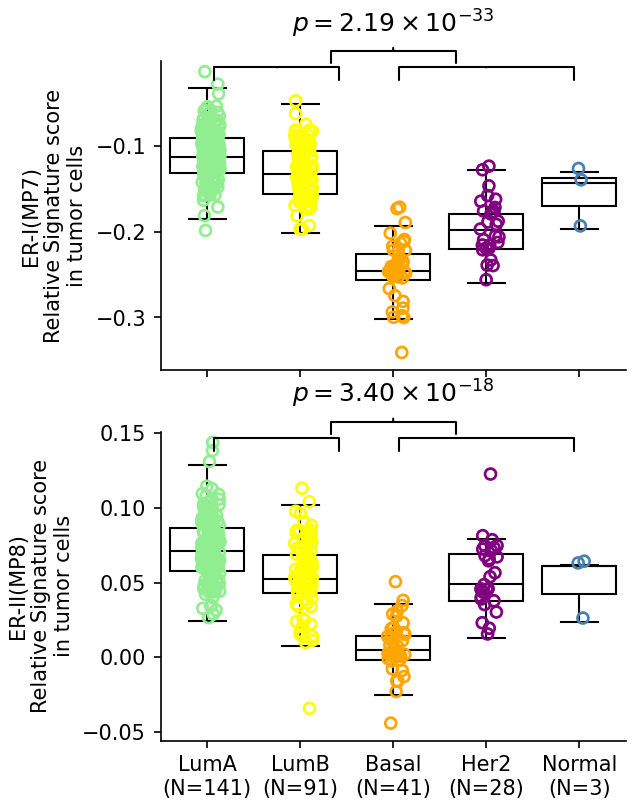

In [66]:
from scipy.stats import ranksums
norm_score = norm_v_score.copy()#loc[norm_v_score['ER-IHC']=='Negative',:]
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}
order=['LumA','LumB','Basal','Her2','Normal']
palette={'Normal': 'steelblue',
        'Basal': 'orange',
        'LumB': 'yellow',
        'LumA': 'lightgreen',
        'Her2': 'purple',}
ylabel='Relative Signature score\nin tumor cells'
x='PAM50'
fig,axs = plt.subplots(2,1,figsize=(4,6),sharex=False,dpi=150)

## Plot EMT-III
ax=axs[1]
y='Tumor.ER-II'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
title=y.replace('Tumor.','')
ax.set(xlabel='',ylabel=f"{title}({MP_anno_map_reverse[title]})\n{ylabel}")
xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels(xticklabels)
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x].isin(['LumA','LumB']),y].values,
                  norm_score.loc[norm_score[x].isin(['Basal','Normal','Her2']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, 1.02), xytext=(0.5, 1.07), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))
ax.annotate('', xy=(0.25, .98), xytext=(0.25, .9801), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'));
ax.annotate('', xy=(0.7, .98), xytext=(0.7, .9801), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=3.5, lengthB=.5', lw=1, color='k'));

## Plot ER-I
ax=axs[0]
y='Tumor.ER-I'
sns.stripplot(data=norm_score,y=y,x=x,ax=ax,palette=palette,order=order,
              marker="$\circ$", ec="face",size=10)
sns.boxplot(data=norm_score,y=y,x=x,ax=ax,order=order,
            showfliers=False,linewidth=1,**PROPS)
title=y.replace('Tumor.','')
ax.set(xlabel='',ylabel=f"{title}({MP_anno_map_reverse[title]})\n{ylabel}")

xticklabels=[]
for handle in ax.get_xticklabels():
    text = handle.get_text()
    xticklabels.append(f"{text}\n(N={(norm_score[x]==text).sum()})")
ax.set_xticklabels([])
##### stats
z,pvalue = ranksums(norm_score.loc[norm_score[x].isin(['LumA','LumB']),y].values,
                  norm_score.loc[norm_score[x].isin(['Basal','Normal','Her2']),y].values)
ax.annotate(format_pvalue_latex(pvalue), xy=(0.5, 1.02), xytext=(0.5, 1.07), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'))
ax.annotate('', xy=(0.25, .98), xytext=(0.25, .9801), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=2.5, lengthB=.5', lw=1, color='k'));
ax.annotate('', xy=(0.7, .98), xytext=(0.7, .9801), xycoords='axes fraction', 
            fontsize=12, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=3.5, lengthB=.5', lw=1, color='k'));


plt.subplots_adjust(wspace=.3)
fig.savefig(f'{FIGURE_FOLDER}/Suppl_2G_ER_PAM50_TCGA.svg',dpi=200,bbox_inches='tight')